# Proyecto Integrador Unidad 1

## Equipo:
### Josué Uriel Martínez Ruíz
### Susana Silva Hernández

Proyecto consiste en un notebook de Google Colab que entrena y compara dos arquitecturas de clasificación
de imágenes (ResNet-18 y EfficientNet-B0) sobre el dataset CIFAR-10.

Colab: https://colab.research.google.com/drive/12tErFSHDNh96n2YuUu-XMiLx-pUQd8I1?usp=sharing

GitHub: https://github.com/josue-mtz/Deeplearning-para-vision-por-computadoras

Drive: https://drive.google.com/drive/folders/19xRYUm9AwJ0meg56MHlzyurTEZzUYBfW?usp=sharing

## EfficientNet-B0

####  Data set: CIFAR-10

Esta parte del notebook cubre la parte que le corresponde a **EfficientNet-B0**.


### 1. Librerías

In [ ]:
#instalacion de torchmetrics
!pip install -q torchmetrics

import os
import time

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

import torchmetrics
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("torchmetrics:", torchmetrics.__version__)


torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
torchmetrics: 1.9.0


### 2. Configuración

In [ ]:
SEED = 42

BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
OPTIMIZER_NAME = "Adam"

TRAIN_SUBSET_SIZE = 20000 #tamaño del subconjunto de entrenamiento (de los 50000 de CIFAR-10 train)
VAL_SUBSET_SIZE = 5000    #tamaño del subconjunto de validación (tomado del mismo train de CIFAR-10)
#El conjunto de prueba usa el test set completo de CIFAR-10 (10000 imágenes) para ambos modelos.

USE_PRETRAINED_WEIGHTS = True #transfer learning

IMG_SIZE = 224 #EfficientNet-B0 espera 224x224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

CIFAR10_CLASSES = ["avión", "automóvil", "pájaro", "gato", "venado", "perro", "rana", "caballo", "barco", "camión"]

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Dispositivo: cuda
GPU: Tesla T4


### 3. Dataset en Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Carpeta persistente del proyecto dentro de nuestro Drive
PROJECT_DIR = "/content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10"
DATA_DIR = os.path.join(PROJECT_DIR, "data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "resultados")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Dataset en:", DATA_DIR)
print("Resultados en:", RESULTS_DIR)


Mounted at /content/drive
Dataset en: /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/data
Resultados en: /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/resultados


In [ ]:
#Resize a 224x224 + normalización con estadísticas de ImageNet, porque se usan pesos preentrenados
# (USE_PRETRAINED_WEIGHTS = True)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

#download=True descarga solo si DATA_DIR no tiene ya los archivos de CIFAR-10
train_full = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=transform
)

print("CIFAR-10 disponible localmente en", DATA_DIR)
print("Train completo:", len(train_full), "| Test:", len(test_dataset))


100%|██████████| 170M/170M [39:28<00:00, 72.0kB/s]


CIFAR-10 disponible localmente en /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/data
Train completo: 50000 | Test: 10000


In [ ]:
#Mismo subconjunto de entrenamiento y validación para ambos modelos,semilla (SEED) y los mismos tamaños definidos
remaining = len(train_full) - TRAIN_SUBSET_SIZE - VAL_SUBSET_SIZE
generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset, _ = random_split(
    train_full,
    [TRAIN_SUBSET_SIZE, VAL_SUBSET_SIZE, remaining],
    generator=generator,
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train:", len(train_subset), "| Val:", len(val_subset), "| Test:", len(test_dataset))


Train: 20000 | Val: 5000 | Test: 10000


### 4. Modelo: EfficientNet-B0

Se usa la implementación oficial de `torchvision.models`, el único cambio
estructural permitido es reemplazar la última capa (`classifier[1]`) para que la salida tenga 10 valores
en vez de 1000.


In [ ]:
def crear_modelo_efficientnet_b0(pretrained=True, num_classes=10):
    weights = "DEFAULT" if pretrained else None
    modelo = torchvision.models.efficientnet_b0(weights=weights)
    modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, num_classes)
    return modelo

modelo = crear_modelo_efficientnet_b0(pretrained=USE_PRETRAINED_WEIGHTS).to(device)

n_parametros = sum(p.numel() for p in modelo.parameters())
n_parametros_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"EfficientNet-B0 — parámetros totales: {n_parametros:,}")
print(f"EfficientNet-B0 — parámetros entrenables: {n_parametros_entrenables:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 191MB/s]


EfficientNet-B0 — parámetros totales: 4,020,358
EfficientNet-B0 — parámetros entrenables: 4,020,358


In [ ]:
criterio = nn.CrossEntropyLoss()

if OPTIMIZER_NAME == "Adam":
    optimizador = torch.optim.Adam(modelo.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizador = torch.optim.SGD(modelo.parameters(), lr=LEARNING_RATE, momentum=0.9)
else:
    raise ValueError(f"Optimizador no soportado: {OPTIMIZER_NAME}")

print("Optimizador:", optimizador)


Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


### 5. Entrenamiento

Se registra por época: loss y accuracy de train y de validación, y la duración de la época (con `time`)
en una tabla de `pandas`.


In [ ]:
def calcular_accuracy(logits, etiquetas):
    predicciones = torch.argmax(logits, dim=1)
    return (predicciones == etiquetas).float().mean().item()


def correr_una_epoca(modelo, loader, criterio, optimizador=None):
    entrenando = optimizador is not None
    modelo.train() if entrenando else modelo.eval()

    perdida_total, acc_total, n_lotes = 0.0, 0.0, 0

    with torch.set_grad_enabled(entrenando):
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

            if entrenando:
                optimizador.zero_grad()

            salidas = modelo(imagenes)
            perdida = criterio(salidas, etiquetas)

            if entrenando:
                perdida.backward()
                optimizador.step()

            perdida_total += perdida.item()
            acc_total += calcular_accuracy(salidas, etiquetas)
            n_lotes += 1

    return perdida_total / n_lotes, acc_total / n_lotes


In [ ]:
historial = []

for epoca in range(1, NUM_EPOCHS + 1):
    inicio = time.time()

    train_loss, train_acc = correr_una_epoca(modelo, train_loader, criterio, optimizador)
    val_loss, val_acc = correr_una_epoca(modelo, val_loader, criterio, optimizador=None)

    duracion = time.time() - inicio

    historial.append({
        "epoca": epoca,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "duracion_seg": duracion,
    })

    print(f"Época {epoca}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
          f"{duracion:.1f}s")

historial_df = pd.DataFrame(historial)
historial_df


Época 1/15 | train_loss=0.4880 train_acc=0.8370 | val_loss=0.2705 val_acc=0.9108 | 113.1s
Época 2/15 | train_loss=0.2485 train_acc=0.9156 | val_loss=0.2792 val_acc=0.9116 | 114.3s
Época 3/15 | train_loss=0.1683 train_acc=0.9421 | val_loss=0.2730 val_acc=0.9126 | 115.4s
Época 4/15 | train_loss=0.1400 train_acc=0.9520 | val_loss=0.2708 val_acc=0.9163 | 115.1s
Época 5/15 | train_loss=0.1121 train_acc=0.9631 | val_loss=0.2891 val_acc=0.9104 | 114.4s
Época 6/15 | train_loss=0.0986 train_acc=0.9665 | val_loss=0.2785 val_acc=0.9244 | 114.6s
Época 7/15 | train_loss=0.0897 train_acc=0.9719 | val_loss=0.2704 val_acc=0.9237 | 114.6s
Época 8/15 | train_loss=0.0791 train_acc=0.9731 | val_loss=0.2842 val_acc=0.9250 | 114.8s
Época 9/15 | train_loss=0.0690 train_acc=0.9757 | val_loss=0.3146 val_acc=0.9209 | 114.5s
Época 10/15 | train_loss=0.0664 train_acc=0.9778 | val_loss=0.2780 val_acc=0.9239 | 114.1s
Época 11/15 | train_loss=0.0608 train_acc=0.9795 | val_loss=0.3260 val_acc=0.9128 | 114.2s
Época 12

,epoca,train_loss,train_acc,val_loss,val_acc,duracion_seg
0,1,0.487982,0.837011,0.270500,0.910799,113.130281
1,2,0.248542,0.915635,0.279224,0.911590,114.282526
2,3,0.168256,0.942093,0.272954,0.912579,115.380296
3,4,0.139998,0.951977,0.270810,0.916337,115.068320
4,5,0.112148,0.963059,0.289137,0.910403,114.370174
5,6,0.098585,0.966504,0.278460,0.924446,114.641074
6,7,0.089744,0.971945,0.270383,0.923655,114.583256
7,8,0.079067,0.973143,0.284235,0.925040,114.756510
8,9,0.068965,0.975739,0.314618,0.920886,114.499653
9,10,0.066444,0.977835,0.278035,0.923853,114.134564


In [ ]:
#Guardar el historial para poder armar luego la tabla comparativa con el notebook de ResNet-18
historial_path = os.path.join(RESULTS_DIR, "historial_efficientnet_b0.csv")
historial_df.to_csv(historial_path, index=False)
print("Historial guardado en:", historial_path)


Historial guardado en: /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/resultados/historial_efficientnet_b0.csv


### 6. Curvas de entrenamiento (loss y accuracy, train y validación)

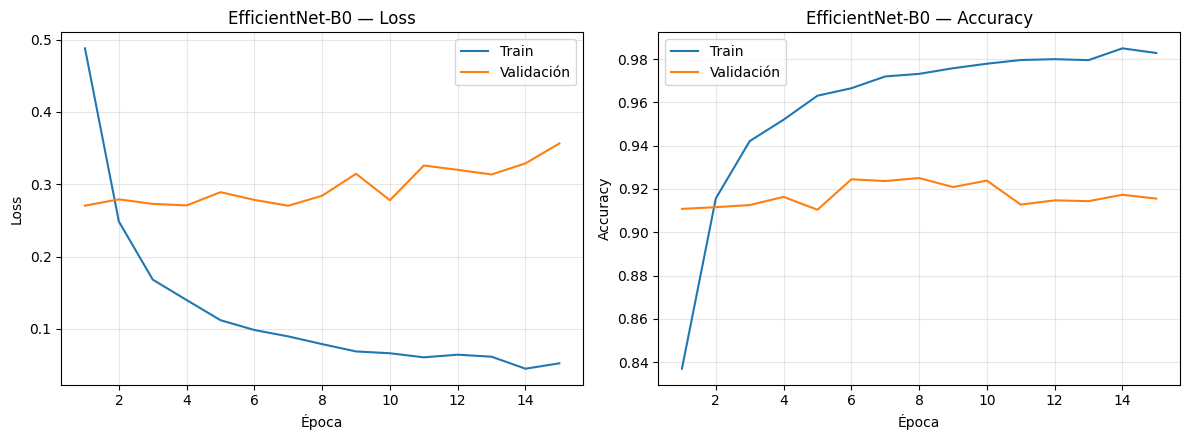

Gráfica guardada en: /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/resultados/curvas_efficientnet_b0.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(historial_df["epoca"], historial_df["train_loss"], label="Train")
axes[0].plot(historial_df["epoca"], historial_df["val_loss"], label="Validación")
axes[0].set_title("EfficientNet-B0 — Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(historial_df["epoca"], historial_df["train_acc"], label="Train")
axes[1].plot(historial_df["epoca"], historial_df["val_acc"], label="Validación")
axes[1].set_title("EfficientNet-B0 — Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
curva_path = os.path.join(RESULTS_DIR, "curvas_efficientnet_b0.png")
plt.savefig(curva_path, dpi=150)
plt.show()
print("Gráfica guardada en:", curva_path)


### 7. Métricas sobre el conjunto de prueba

Las cuatro métricas con `torchmetrics`, promedio macro entre las 10
clases: accuracy, precisión, recall y F1-score y también se calcula la matriz de confusión.


In [ ]:
metrica_accuracy = MulticlassAccuracy(num_classes=10, average="macro").to(device)
metrica_precision = MulticlassPrecision(num_classes=10, average="macro").to(device)
metrica_recall = MulticlassRecall(num_classes=10, average="macro").to(device)
metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(device)
metrica_matriz_confusion = MulticlassConfusionMatrix(num_classes=10).to(device)

modelo.eval()
with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        salidas = modelo(imagenes)
        predicciones = torch.argmax(salidas, dim=1)

        metrica_accuracy.update(predicciones, etiquetas)
        metrica_precision.update(predicciones, etiquetas)
        metrica_recall.update(predicciones, etiquetas)
        metrica_f1.update(predicciones, etiquetas)
        metrica_matriz_confusion.update(predicciones, etiquetas)

resultados_test = {
    "modelo": "EfficientNet-B0",
    "accuracy": metrica_accuracy.compute().item(),
    "precision": metrica_precision.compute().item(),
    "recall": metrica_recall.compute().item(),
    "f1_score": metrica_f1.compute().item(),
    "n_parametros": n_parametros,
    "duracion_promedio_epoca_seg": historial_df["duracion_seg"].mean(),
}

metricas_df = pd.DataFrame([resultados_test])
metricas_df


,modelo,accuracy,precision,recall,f1_score,n_parametros,duracion_promedio_epoca_seg
0,EfficientNet-B0,0.9171,0.918449,0.9171,0.917009,4020358,114.408317


In [ ]:
metricas_path = os.path.join(RESULTS_DIR, "metricas_test_efficientnet_b0.csv")
metricas_df.to_csv(metricas_path, index=False)
print("Métricas guardadas en:", metricas_path)


Métricas guardadas en: /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/resultados/metricas_test_efficientnet_b0.csv


### 8. Matriz de confusión

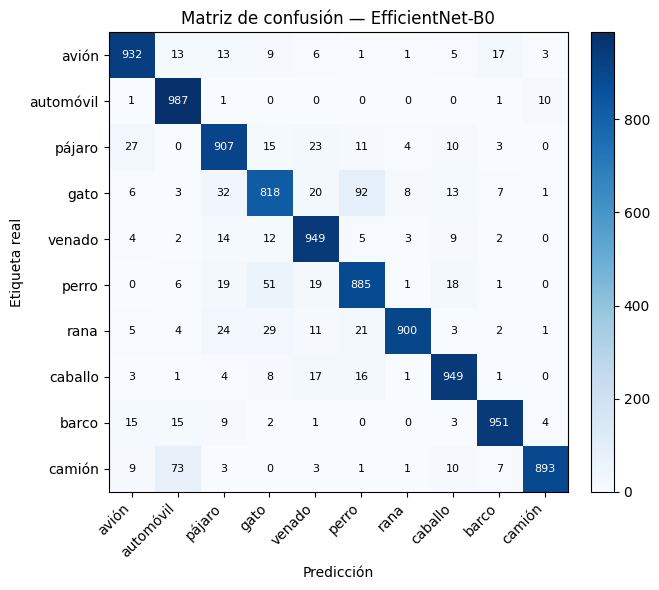

Matriz guardada en: /content/drive/MyDrive/MiniProyecto_Unidad1_CIFAR10/resultados/matriz_confusion_efficientnet_b0.png


In [ ]:
matriz = metrica_matriz_confusion.compute().cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matriz, cmap="Blues")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión — EfficientNet-B0")

for i in range(10):
    for j in range(10):
        ax.text(j, i, int(matriz[i, j]), ha="center", va="center",
                 color="white" if matriz[i, j] > matriz.max() / 2 else "black", fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
matriz_path = os.path.join(RESULTS_DIR, "matriz_confusion_efficientnet_b0.png")
plt.savefig(matriz_path, dpi=150)
plt.show()
print("Matriz guardada en:", matriz_path)


In [ ]:
#Par de clases con mayor confusión (fuera de la diagonal, es decir, excluyendo los aciertos)
matriz_sin_diagonal = matriz.copy()
np.fill_diagonal(matriz_sin_diagonal, 0)

idx = np.unravel_index(np.argmax(matriz_sin_diagonal), matriz_sin_diagonal.shape)
clase_real, clase_predicha = CIFAR10_CLASSES[idx[0]], CIFAR10_CLASSES[idx[1]]
n_confusiones = matriz_sin_diagonal[idx]

print(f"Par con mayor confusión: real='{clase_real}' predicho como '{clase_predicha}' "
      f"({int(n_confusiones)} imágenes de prueba)")


Par con mayor confusión: real='gato' predicho como 'perro' (92 imágenes de prueba)


### Reporte de diseño

**1. Arquitectura recomendada**

Comparando con ResNet-18 (entrenado bajo las mismas condiciones), se recomienda **EfficientNet-B0** obtuvo mejor accuracy (91.71% vs. 87.01%) y mejor F1-score (0.9170 vs. 0.8699), usando además ~2.8 veces menos parámetros (4,020,358 vs. 11,181,642).

El único costo es una época más lenta (114.4 s vs. 81.3 s en GPU Tesla T4), pero la ganancia en desempeño y eficiencia de parámetros compensa ese costo.

**2. Hiperparámetros usados (EfficientNet-B0)**
- Learning rate: `0.001`
- Optimizador: `Adam`
- Número de épocas: `15`
- Batch size: `64`
- Tamaño del subconjunto de entrenamiento: `20000` (validación: `5000`)
- Uso de pesos preentrenados: `Sí, weights="DEFAULT"` (transfer learning)

**3. Hardware de entrenamiento y duración por época**

Dispositivo: `cuda` — GPU `Tesla T4`, duración promedio por época: **114.41 s**.

**4. Diagnóstico de las curvas de entrenamiento**

Se observa *sobreajuste (overfitting)* en el train_loss baja de forma continua hasta ~0.05, mientras que el val_loss deja de mejorar alrededor de la época 5 - 6 y termina subiendo (de 0.27 a 0.36 en la época 15).

En paralelo train_accuracy sigue subiendo hasta 98%, mientras val_accuracy se estanca entre 91% y 92%, esa divergencia train-val (mejora en train, estancamiento / empeoramiento en val) es la evidencia clara de sobreajuste, ayudaría agregar data augmentation, weight decay o early stopping.

**5. Parámetros vs. desempeño (capacidad frente a eficiencia)**

EfficientNet-B0 usa **4,020,358** parámetros y logra F1 = **0.9170**, frente a los 11,181,642 parámetros y F1 = 0.8699 de ResNet-18.

Es decir con menos de la mitad de los parámetros, EfficientNet-B0 generaliza mejor y esto refleja el diseño de "compound scaling" de EfficientNet, que balancea profundidad, ancho y resolución en vez de simplemente apilar más capas, logrando una arquitectura más eficiente por parámetro para esta tarea.

**6. Par de clases con mayor confusión (EfficientNet-B0)**

Par con mayor confusión: real = *gato*, predicho como *perro* — **92 imágenes** de prueba (la confusión inversa, perro a gato, fue menor: 51 imágenes).
- Ambas clases comparten texturas de pelaje similares (pelo corto/suave con patrones de color variables), lo que confunde a los filtros convolucionales orientados a textura.
- Comparten estructuras faciales parecidas en ciertas razas/ángulos: ojos grandes, hocico corto, orejas   triangulares.
- Suelen aparecer en las mismas poses domésticas (sentados, acostados, mirando a cámara), reduciendo la variabilidad visual entre ambas clases.
- Aun así, EfficientNet-B0 redujo bastante esta confusión frente a ResNet-18 (donde perro→gato llegaba a 122 imágenes), lo que sugiere que su extracción de características es más fina para distinguir estos dos animales.

## EfficientNet vs Resnet

**1. Arquitectura recomendada por el equipo**

Se recomienda usar **EfficientNet-B0** con las mismas condiciones de entrenamiento obtuvo mejor desempeño en las
cuatro métricas (accuracy 91.71% vs. 87.01%, F1 0.9170 vs. 0.8699) y además usa *menos parámetros* (4,020,358 vs. 11,181,642), es decir mejor exactitud con un modelo más pequeño.

El único costo es que cada época tardó más (114.4 s vs. 81.3 s), probablemente por el mayor costo computacional por parámetro de los bloques MBConv de EfficientNet frente a las convoluciones estándar de ResNet, aun así la ganancia en desempeño justifica la arquitectura recomendada.

**2. Hiperparámetros usados (los mismos para ambos modelos)**
- Learning rate: `0.001`
- Optimizador: `Adam`
- Número de épocas: `15`
- Batch size: `64`
- Tamaño del subconjunto de entrenamiento: `20000` (validación: `5000`, prueba: `10000`, el test set completo)
- Uso de pesos preentrenados (transfer learning): `Sí, weights="DEFAULT"` para ambos modelos

**3. Hardware de entrenamiento y duración por época**

Dispositivo: `cuda` — GPU `Tesla T4`.
- Duración promedio por época ResNet-18: **81.30 s**
- Duración promedio por época EfficientNet-B0: **114.41 s**

**4. Diagnóstico de las curvas de entrenamiento**
Ambos modelos muestran **sobreajuste (overfitting)**:
- **ResNet-18**: el train_loss baja de forma sostenida hasta ~0.04, mientras que el val_loss deja de bajar desde la época 2-3 y oscila entre 0.43 y 0.74 sin tendencia clara de mejora; el val_accuracy se estanca alrededor de 82 - 88% mientras el train_accuracy sigue subiendo hasta 98.5%. La brecha de train-val y la inestabilidad del val_loss son la evidencia del sobreajuste.

- **EfficientNet-B0**: el patrón es más claro: train_loss baja continuamente hasta ~0.05, pero val_loss *sube* de 0.27 (época 1) a 0.36 (época 15) a partir de la época 5-6, mientras train_accuracy sigue subiendo (83% a 98%) y val_accuracy se estanca en ~91-92%. Esa divergencia (train mejora, val empeora) es la firma clásica de sobreajuste.

- En ambos casos, más regularización (data augmentation, weight decay, dropout o early stopping) ayudaría a cerrar la brecha train-val.

**5. Parámetros vs. desempeño (capacidad frente a eficiencia)**
| Modelo | Parámetros | Accuracy | F1-score |
|---|---|---|---|
| ResNet-18 | 11,181,642 | 87.01% | 0.8699 |
| EfficientNet-B0 | 4,020,358 | 91.71% | 0.9170 |

EfficientNet-B0 logra *mejor desempeño con ~2.8x menos parámetros* que ResNet-18, esto confirma la idea de diseño detrás de EfficientNet (compound scaling):

En vez de agregar capacidad "a lo bruto", escala profundidad, ancho y resolución de forma balanceada, logrando una arquitectura más eficiente en parámetros para esta tarea. ResNet-18, con más parámetros y una arquitectura más simple, no logra aprovechar esa capacidad extra en el conjunto de datos y condiciones usadas aquí, y de hecho generaliza peor (mayor sobreajuste, según el punto 4).

**6. Par de clases con mayor confusión en cada matriz**

- **ResNet-18**: `perro` real confundido con `gato` predicho — *122 imágenes*.
Perros y gatos comparten texturas de pelaje, formas faciales redondeadas (ojos grandes, hocico corto en ciertas razas/ángulos), orejas similares y poses domésticas comunes (sentados, acostados, mirando a cámara), lo que dificulta que los filtros convolucionales de una red más simple separen bien ambas clases.

- **EfficientNet-B0**: `gato` real confundido con `perro` predicho — *92 imágenes* (la confusión inversa, perro→gato, bajó a solo 51). Aunque EfficientNet-B0 reduce bastante esta confusión frente a ResNet-18, sigue siendo el par más difícil para ambos modelos, lo que sugiere que la dificultad es intrínseca al dataset (animales pequeños, 32×32 originales, mismo contexto doméstico) más que un defecto de una sola arquitectura.

## Tabla comparativa final — ResNet-18 vs. EfficientNet-B0

| Métrica (conjunto de prueba) | ResNet-18 | EfficientNet-B0 |
|---|---|---|
| Accuracy | 87.01% | **91.71%** |
| Precisión (macro) | 87.05% | **91.84%** |
| Recall (macro) | 87.01% | **91.71%** |
| F1-score (macro) | 0.8699 | **0.9170** |
| N.º de parámetros | 11,181,642 | **4,020,358** |
| Duración promedio por época | **81.30 s** | 114.41 s |
| Par de clases más confundido | perro → gato (122 img.) | gato → perro (92 img.) |

*(Condiciones idénticas para ambos: SEED=42, batch size 64, Adam, lr=0.001, 15 épocas, 20,000 imágenes de
entrenamiento, 5,000 de validación, 10,000 de prueba, pesos preentrenados en ImageNet, GPU Tesla T4.)*

## Conclusión

Bajo condiciones idénticas de entrenamiento, **EfficientNet-B0 superó a ResNet-18 en las cuatro métricas de
evaluación** (accuracy, precisión, recall y F1-score), y lo hizo usando **menos de la mitad de los
parámetros** (4.02M vs. 11.18M), confirmando en la práctica, la idea de diseño detrás de EfficientNet: el
"compound scaling" (escalar profundidad, ancho y resolución de forma balanceada) logra una arquitectura más
eficiente por parámetro que apilar bloques convolucionales estándar como en ResNet.

La única ventaja medible de ResNet-18 fue la velocidad de entrenamiento: cada época tomó en promedio 81.3 s
frente a 114.4 s de EfficientNet-B0 (~29% más rápido), por el menor costo computacional de sus convoluciones
estándar frente a los bloques MBConv.

Ambos modelos mostraron **sobreajuste** (brecha creciente entre train y validación), aunque fue más marcado e
inestable en ResNet-18 donde el val_loss osciló fuertemente sin tendencia de mejora después de las primeras
épocas; en EfficientNet-B0 el sobreajuste fue más gradual y controlado.

En los dos modelos, el par de clases
más difícil de distinguir fue **perro vs. gato**, consistente con la similitud visual intrínseca de esas
categorías en CIFAR-10 (pelaje, forma facial, poses domésticas), aunque EfficientNet-B0 redujo esa confusión
en términos relativos.

**Recomendación usar EfficientNet-B0** para este problema, ya que ofrece mejor exactitud y
generalización con un modelo significativamente más liviano; ResNet-18 solo sería preferible en escenarios
donde el tiempo de entrenamiento o inferencia sea la restricción más crítica por encima del desempeño.